In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
raw_dir = Path("../data/raw")

files = [
    raw_dir / "flights_2025_01.csv",
    raw_dir / "flights_2025_02.csv",
    raw_dir / "flights_2025_03.csv",
]

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    print(file.name, temp.shape)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

flights_2025_01.csv (539747, 26)
flights_2025_02.csv (504884, 26)
flights_2025_03.csv (600872, 26)


(1645503, 26)

In [3]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(1611046, 26)

In [4]:
month_delay = (
    completed
    .groupby("MONTH")["ARR_DEL15"]
    .agg(["count", "mean"])
)

month_delay["late_rate_percent"] = month_delay["mean"] * 100

month_delay

,count,mean,late_rate_percent
MONTH,,,
1,522269,0.187892,18.789168
2,496476,0.207668,20.766764
3,592301,0.195904,19.590377


In [5]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

In [6]:
train_data = completed[completed["MONTH"] == 1].copy()
val_data = completed[completed["MONTH"] == 2].copy()
test_data = completed[completed["MONTH"] == 3].copy()

X_train = train_data[features]
y_train = train_data[target].astype(int)

X_val = val_data[features]
y_val = val_data[target].astype(int)

X_test = test_data[features]
y_test = test_data[target].astype(int)

X_train.shape, X_val.shape, X_test.shape

((522269, 12), (496476, 12), (592301, 12))

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [8]:
hgb_temporal_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_temporal_model.fit(X_train, y_train)

val_probs = hgb_temporal_model.predict_proba(X_val)[:, 1]
test_probs = hgb_temporal_model.predict_proba(X_test)[:, 1]

In [9]:
thresholds = np.arange(0.10, 0.501, 0.01)

val_results = []

for threshold in thresholds:
    preds = (val_probs >= threshold).astype(int)

    val_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_val, preds),
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "f1": f1_score(y_val, preds, zero_division=0)
    })

val_results_df = pd.DataFrame(val_results)

val_results_df.sort_values("f1", ascending=False).head(15)

,threshold,accuracy,precision,recall,f1
0,0.10,0.339404,0.220533,0.860546,0.351092
1,0.11,0.375537,0.222594,0.805232,0.348774
2,0.12,0.408701,0.223435,0.746222,0.343899
3,0.13,0.437687,0.223428,0.689802,0.337530
4,0.14,0.463823,0.223552,0.639609,0.331308
5,0.15,0.488243,0.223884,0.593655,0.325146
6,0.16,0.510383,0.223352,0.548069,0.317369
7,0.17,0.530795,0.222955,0.506760,0.309668
8,0.18,0.549003,0.222197,0.468594,0.301452
9,0.19,0.567018,0.222728,0.435772,0.294787


In [10]:
best_threshold = val_results_df.sort_values("f1", ascending=False).iloc[0]["threshold"]

test_preds = (test_probs >= best_threshold).astype(int)

print("Temporal Validation Final Test")
print("Train month: January 2025")
print("Validation month: February 2025")
print("Test month: March 2025")
print("Threshold chosen on February:", best_threshold)
print()
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("F1:", f1_score(y_test, test_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

print()
print(classification_report(y_test, test_preds, zero_division=0))

Temporal Validation Final Test
Train month: January 2025
Validation month: February 2025
Test month: March 2025
Threshold chosen on February: 0.1

Accuracy: 0.33452585762981996
Precision: 0.20397724007126847
Recall: 0.8258182946377786
F1: 0.32714870255903394
ROC-AUC: 0.5302348328880853

              precision    recall  f1-score   support

           0       0.84      0.21      0.34    476267
           1       0.20      0.83      0.33    116034

    accuracy                           0.33    592301
   macro avg       0.52      0.52      0.33    592301
weighted avg       0.71      0.33      0.34    592301



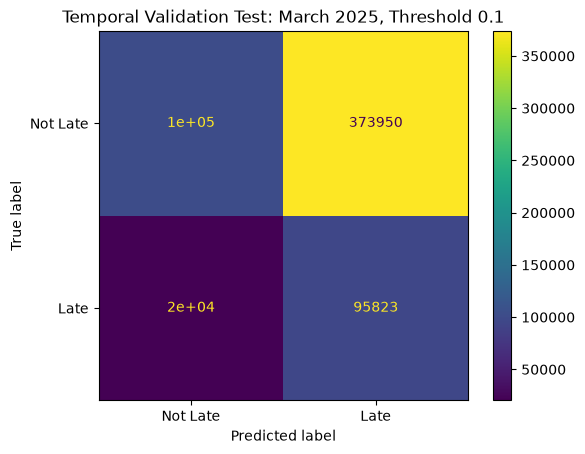

In [11]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title(f"Temporal Validation Test: March 2025, Threshold {best_threshold}")
plt.show()

In [12]:
best_val = val_results_df.sort_values("f1", ascending=False).iloc[0].to_dict()

test_result = {
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
}

comparison = pd.DataFrame([
    {"split": "February validation", **best_val},
    {"split": "March test", **test_result}
])

comparison

,split,threshold,accuracy,precision,recall,f1
0,February validation,0.1,0.339404,0.220533,0.860546,0.351092
1,March test,0.1,0.334526,0.203977,0.825818,0.327149


In [13]:
Path("../visuals").mkdir(exist_ok=True)

val_results_df.to_csv("../visuals/temporal_validation_threshold_results.csv", index=False)
comparison.to_csv("../visuals/temporal_validation_comparison.csv", index=False)

comparison

,split,threshold,accuracy,precision,recall,f1
0,February validation,0.1,0.339404,0.220533,0.860546,0.351092
1,March test,0.1,0.334526,0.203977,0.825818,0.327149


The temporal validation experiment showed that the model did not generalize well from January to March. Although the model achieved a stronger F1-score in the January random split, performance dropped when the model was trained on January, tuned on February, and tested on March.

The best threshold selected on February was 0.10. On the March test set, the model achieved high recall but low precision and low overall accuracy. The ROC-AUC was close to 0.53, meaning the model only ranked March delay risk slightly better than random.

This suggests that scheduled flight information alone is not enough for strong future-month delay prediction. Additional predictive signals, such as actual departure delay, weather, airport congestion, or previous-leg aircraft delay, may be needed to improve generalization.